# CSE 2600 HW 2

## Q1

Bin Means Result:
[ 5.2  5.2  5.2  5.2  5.2  5.2  5.2  5.2  5.2  5.2  7.4  7.4  7.4  7.4
  7.4  7.4  7.4  7.4  7.4  7.4 10.4 10.4 10.4 10.4 10.4 10.4 10.4 10.4
 10.4 10.4]
SMOOTHING BY BIN MEANS - USPS Delivery Data

Original Data (30 days):
[6, 7, 6, 7, 7, 6, 11, 4, 8, 6, 6, 12, 2, 8, 12, 5, 7, 8, 6, 11, 6, 8, 9, 11, 5, 9, 8, 9, 8, 12]

Step 1 - Sorted Data:
[2, 4, 5, 5, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 9, 9, 9, 11, 11, 11, 12, 12, 12]

Step 2 - Partition into bins (depth = 10):
  Bin 1: [2, 4, 5, 5, 6, 6, 6, 6, 6, 6]
  Bin 2: [6, 7, 7, 7, 7, 8, 8, 8, 8, 8]
  Bin 3: [8, 9, 9, 9, 11, 11, 11, 12, 12, 12]

Step 3 - Calculate Bin Means:
  Bin 1 mean: 5.20
  Bin 2 mean: 7.40
  Bin 3 mean: 10.40

Step 4 - Smoothed Data (each value replaced by bin mean):
[np.float64(5.2), np.float64(5.2), np.float64(5.2), np.float64(5.2), np.float64(5.2), np.float64(5.2), np.float64(5.2), np.float64(5.2), np.float64(5.2), np.float64(5.2), np.float64(7.4), np.float64(7.4), np.float64(7.4), n

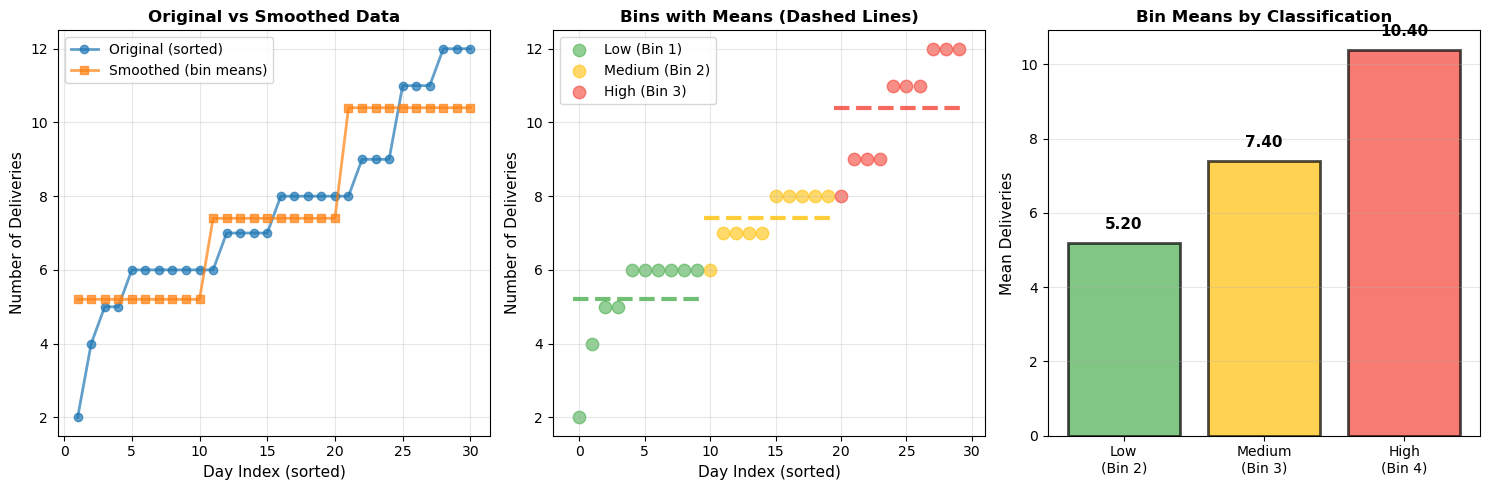


INTERPRETATION
• Low delivery days (Bin 1): 5.20 items on average
• Medium delivery days (Bin 2): 7.40 items on average
• High delivery days (Bin 3): 10.40 items on average


In [6]:
import numpy as np

#data set 
data = np.array([6, 7, 6, 7, 7, 6, 11, 4, 8, 6, 6, 12, 2, 8, 12, 5, 7, 8, 6, 11, 6, 8, 9, 11, 5, 9, 8, 9, 8, 12])

#Part A: Smoothing by bin means
sorted_data = np.sort(data)
bin_depth = 10
bin_means_result = []

for i in range(0, len(sorted_data), bin_depth):
    bin_vals = sorted_data[i:i+bin_depth]
    mean_val = np.mean(bin_vals)
    bin_means_result.extend([mean_val]*len(bin_vals))

bin_means_result = np.array(bin_means_result)

print("Bin Means Result:")
print(bin_means_result)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# USPS delivery data for September
delivery_data = [6, 7, 6, 7, 7, 6, 11, 4, 8, 6, 6, 12, 2, 8, 12, 5, 7, 8, 6, 11, 6, 8, 9, 11, 5, 9, 8, 9, 8, 12]

print("="*70)
print("SMOOTHING BY BIN MEANS - USPS Delivery Data")
print("="*70)
print(f"\nOriginal Data ({len(delivery_data)} days):")
print(delivery_data)

# Step 1: Sort the data
sorted_data = sorted(delivery_data)
print(f"\nStep 1 - Sorted Data:")
print(sorted_data)

# Step 2: Partition into bins of depth 10
bin_depth = 10
bins = [sorted_data[i:i+bin_depth] for i in range(0, len(sorted_data), bin_depth)]

print(f"\nStep 2 - Partition into bins (depth = {bin_depth}):")
for i, bin_data in enumerate(bins, 1):
    print(f"  Bin {i}: {bin_data}")

# Step 3: Calculate bin means
bin_means = [np.mean(bin_data) for bin_data in bins]
print(f"\nStep 3 - Calculate Bin Means:")
for i, (bin_data, mean) in enumerate(zip(bins, bin_means), 1):
    print(f"  Bin {i} mean: {mean:.2f}")

# Step 4: Replace each value in bin with bin mean (smoothing)
smoothed_data = []
for bin_data, mean in zip(bins, bin_means):
    smoothed_data.extend([mean] * len(bin_data))

print(f"\nStep 4 - Smoothed Data (each value replaced by bin mean):")
print([round(x, 2) for x in smoothed_data])

# Step 5: Classify bins as Low, Medium, High
bin_labels = ['Low', 'Medium', 'High']
print(f"\nStep 5 - Classification:")
for i, (mean, label) in enumerate(zip(bin_means, bin_labels), 1):
    print(f"  Bin {i} (mean={mean:.2f}): {label} delivery days")
    print(f"    Original values: {bins[i-1]}")
    print(f"    Smoothed value: {mean:.2f}")

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Bin': [f'Bin {i+1}' for i in range(len(bins))],
    'Classification': bin_labels,
    'Bin Mean': [round(m, 2) for m in bin_means],
    'Original Values': [str(b) for b in bins],
    'Count': [len(b) for b in bins]
})

print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(summary_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Original vs Smoothed Data
axes[0].plot(range(1, len(sorted_data) + 1), sorted_data, 'o-', 
             label='Original (sorted)', linewidth=2, markersize=6, alpha=0.7)
axes[0].plot(range(1, len(smoothed_data) + 1), smoothed_data, 's-', 
             label='Smoothed (bin means)', linewidth=2, markersize=6, alpha=0.7)
axes[0].set_xlabel('Day Index (sorted)', fontsize=11)
axes[0].set_ylabel('Number of Deliveries', fontsize=11)
axes[0].set_title('Original vs Smoothed Data', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Bin Visualization with horizontal lines
colors = ['#4CAF50', '#FFC107', '#F44336']  # green, yellow, red
for i, (bin_data, mean, color, label) in enumerate(zip(bins, bin_means, colors, bin_labels)):
    start_idx = i * bin_depth
    end_idx = start_idx + len(bin_data)
    axes[1].scatter(range(start_idx, end_idx), bin_data, 
                   color=color, s=80, alpha=0.6, label=f'{label} (Bin {i+1})')
    axes[1].hlines(mean, start_idx - 0.5, end_idx - 0.5, 
                  colors=color, linewidth=3, linestyles='dashed', alpha=0.8)
axes[1].set_xlabel('Day Index (sorted)', fontsize=11)
axes[1].set_ylabel('Number of Deliveries', fontsize=11)
axes[1].set_title('Bins with Means (Dashed Lines)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Distribution by Classification
bin_positions = np.arange(len(bins))
axes[2].bar(bin_positions, bin_means, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
for i, (pos, mean) in enumerate(zip(bin_positions, bin_means)):
    axes[2].text(pos, mean + 0.3, f'{mean:.2f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].set_xticks(bin_positions)
axes[2].set_xticklabels([f'{label}\n(Bin {i+1})' for i, label in enumerate(bin_labels, 1)])
axes[2].set_ylabel('Mean Deliveries', fontsize=11)
axes[2].set_title('Bin Means by Classification', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print(f"• Low delivery days (Bin 1): {bin_means[0]:.2f} items on average")
print(f"• Medium delivery days (Bin 2): {bin_means[1]:.2f} items on average") 
print(f"• High delivery days (Bin 3): {bin_means[2]:.2f} items on average")
print("="*70)